# Fragmentation tests

The purpose of this notebook is to compare the fragmentation performances of different solvers on synthetic cases. The score associated with a solver will be the sum of remaining spaces of occupied servers minus the one with the most empty space and the total remaining space. This should allow for fragmentation comparison.

In [1]:
%matplotlib inline

from vm_allocation.models import Context, Server, Solver, VM
from vm_allocation.solvers import CPSATSolver, FFDSolver, PLNESolver

In [2]:
def score_total_remaining_space(context: Context) -> int:
    score = 0
    for server in context.get_servers():
        if len(server.vms) > 0:
            score += sum(server.capacities().values()) - server.cpu_usage - server.ram_usage - server.storage_usage - server.bw_usage
    return score

In [3]:
def score_remaining_minus_most_empty(context: Context) -> int:
    score = 0
    maximum = 0
    for server in context.get_servers():
        if len(server.vms) > 0:
            value = sum(server.capacities().values()) - server.cpu_usage - server.ram_usage - server.storage_usage - server.bw_usage
            score += value
            if value > maximum:
                maximum = value
    return score - maximum

## Test Case 1 : Bare minimum (number of servers)

Let there be 3 servers of size 2, 5, 10 and 15 VMs of size 1. The optimal solution should be to fill the servers of size 5 and 10.

In [4]:
def test_case_1(solver: Solver) -> tuple[Context, int, int]:
    context = Context([Server(1, 2, 2, 2, 2), Server(2, 5, 5, 5, 5), Server(3, 10, 10, 10, 10)])
    vms = [VM(i, 1, 1, 1, 1) for i in range(15)]
    solution = solver.solve(vms, context)
    if solution is None:
        return context, 0,0
    return solution, score_total_remaining_space(solution), score_remaining_minus_most_empty(solution)

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

Scores : (0, 0)


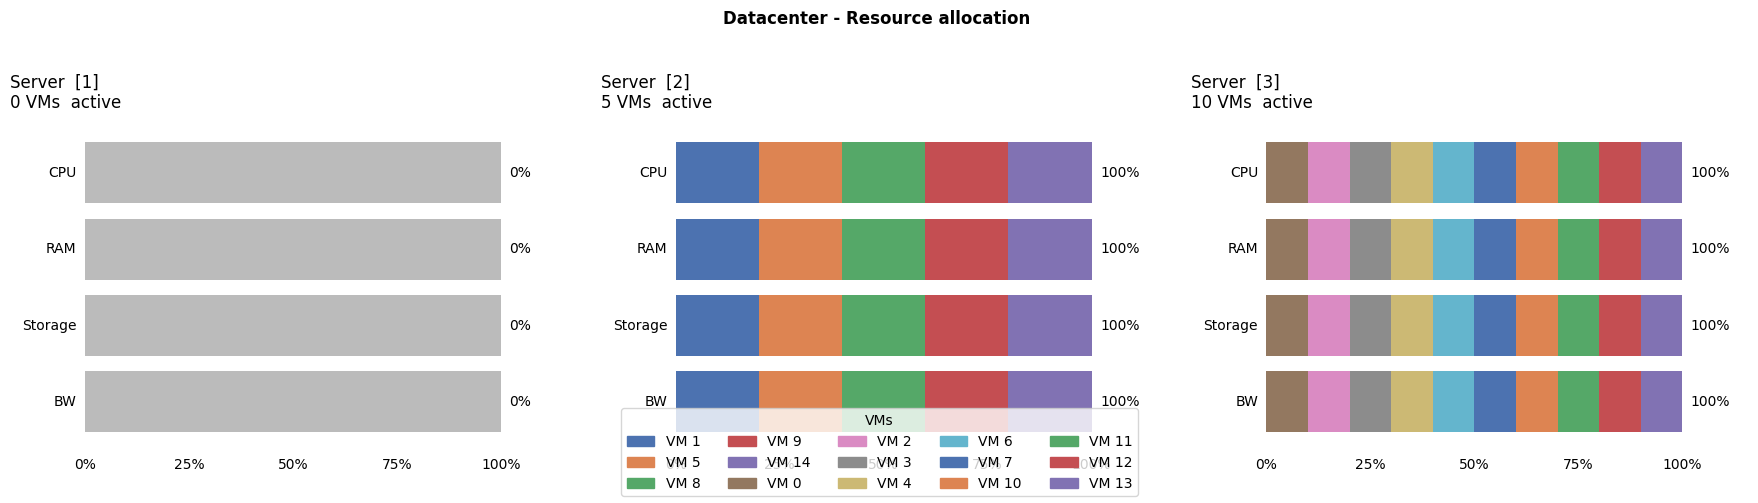

In [5]:
solution, remaining_space, remaining_minus_most_empty = test_case_1(CPSATSolver(0.5, 0.5))
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

### FFD

Scores : (8, 0)


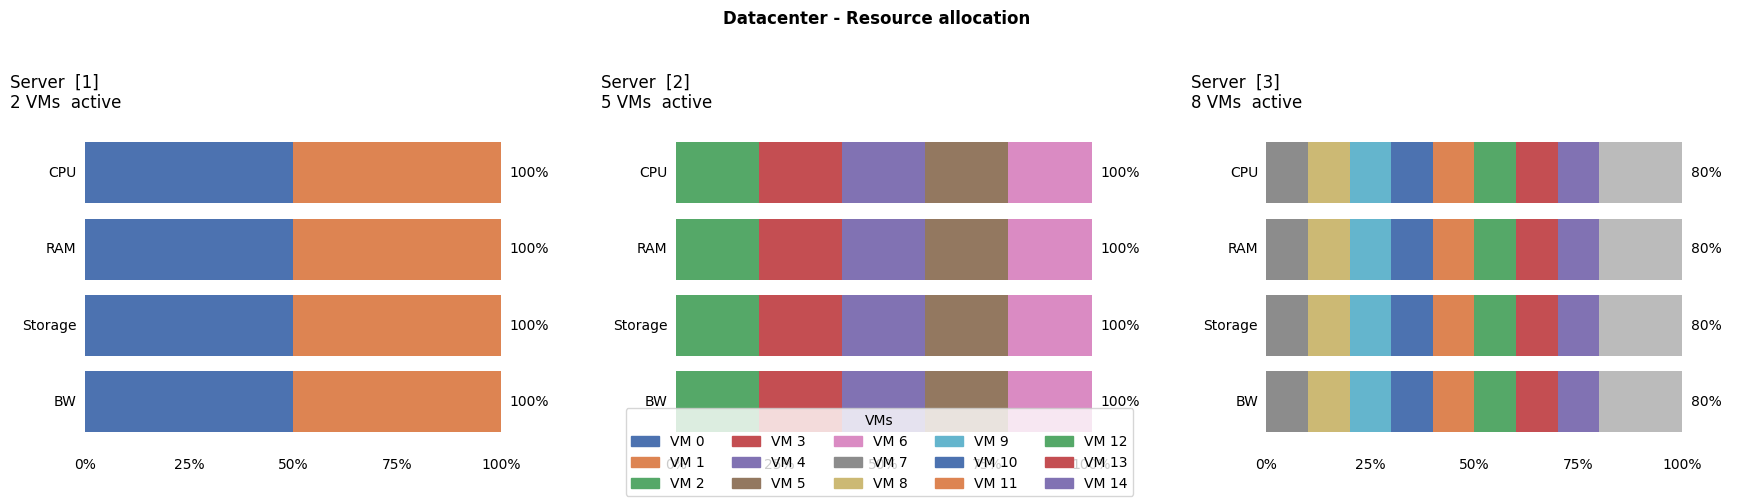

In [6]:
solution, remaining_space, remaining_minus_most_empty = test_case_1(FFDSolver())
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

Scores : (0, 0)


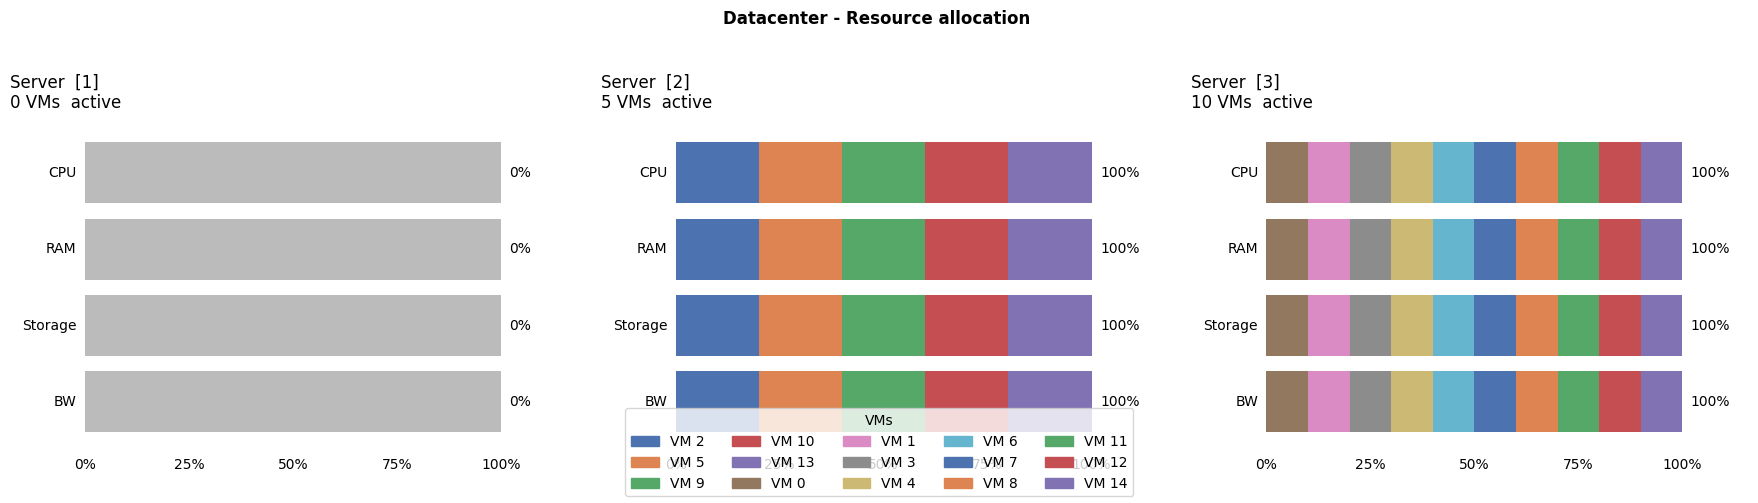

In [7]:
solution, remaining_space, remaining_minus_most_empty = test_case_1(PLNESolver(0.5, 0.5))
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

## Test Case 2 : Ordering matters

Let there be 2 servers of size 11 and 11, we provide a list of VMs of sizes [1, 2, 3, 4, 3, 2, 1]. The optimal solution should be to fill completely one server with [1, 2, 3, 4, 1] and the other one with [3, 2].

In [8]:
def test_case_2(solver: Solver) -> tuple[Context, int, int]:
    context = Context([Server(1, 11, 11, 11, 11), Server(2, 11, 11, 11, 11)])
    vms = [
        VM(i,
        i + 1 if i < 4 else 4 - ((i + 1) % 4),
        i + 1 if i < 4 else 4 - ((i + 1) % 4),
        i + 1 if i < 4 else 4 - ((i + 1) % 4),
        i + 1 if i < 4 else 4 - ((i + 1) % 4)
        ) for i in range(7)]
    solution = solver.solve(vms, context)
    if solution is None:
        return context, 0,0
    return solution, score_total_remaining_space(solution), score_remaining_minus_most_empty(solution)

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

Scores : (24, 0)


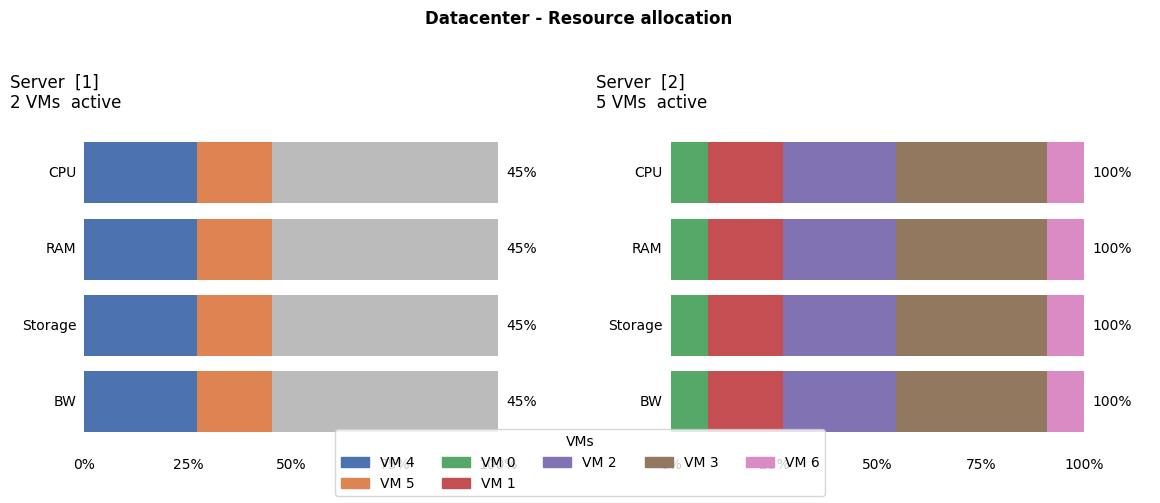

In [9]:
solution, remaining_space, remaining_minus_most_empty = test_case_2(CPSATSolver(0.5, 0.5))
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

### FFD

Scores : (24, 0)


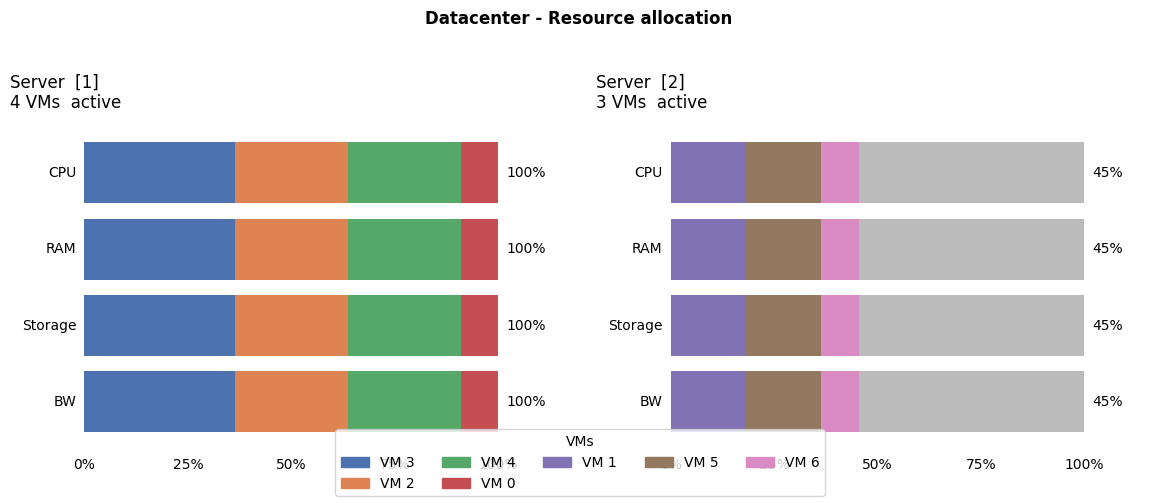

In [10]:
solution, remaining_space, remaining_minus_most_empty = test_case_2(FFDSolver())
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

Scores : (24, 0)


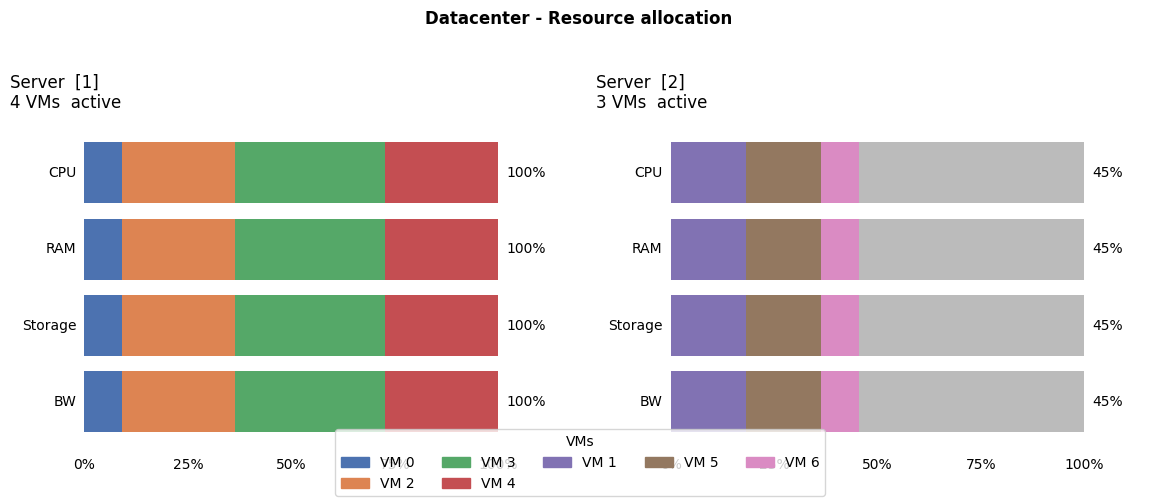

In [11]:
solution, remaining_space, remaining_minus_most_empty = test_case_2(PLNESolver(0.5, 0.5))
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

## Test Case 3 : Smaller is better

Let there be 3 servers of sizes [5, 5, 3]. We provide the VMs [4, 3]. The optimal solution would be to use one of the size 5 server and the size 3.

In [12]:
def test_case_3(solver: Solver) -> tuple[Context, int, int]:
    context = Context([Server(1, 5, 5, 5, 5), Server(2, 5, 5, 5, 5), Server(3, 3, 3, 3, 3)])
    vms = [VM(0, 4,4,4,4), VM(1,3,3,3,3)]
    solution = solver.solve(vms, context)
    if solution is None:
        return context, 0,0
    return solution, score_total_remaining_space(solution), score_remaining_minus_most_empty(solution)

### CP-SAT (migration weight = 0.5, fragmentation weight = 0.5)

Scores : (4, 0)


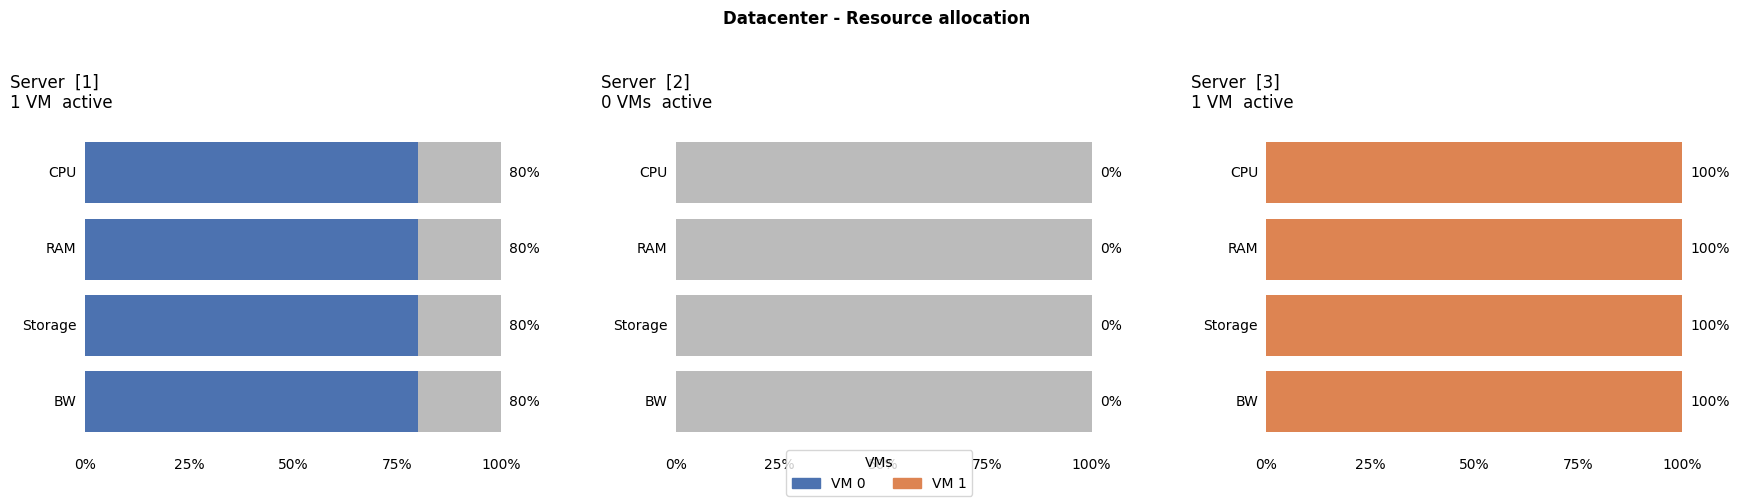

In [13]:
solution, remaining_space, remaining_minus_most_empty = test_case_3(CPSATSolver(0.5, 0.5))
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

### FFD

Scores : (12, 4)


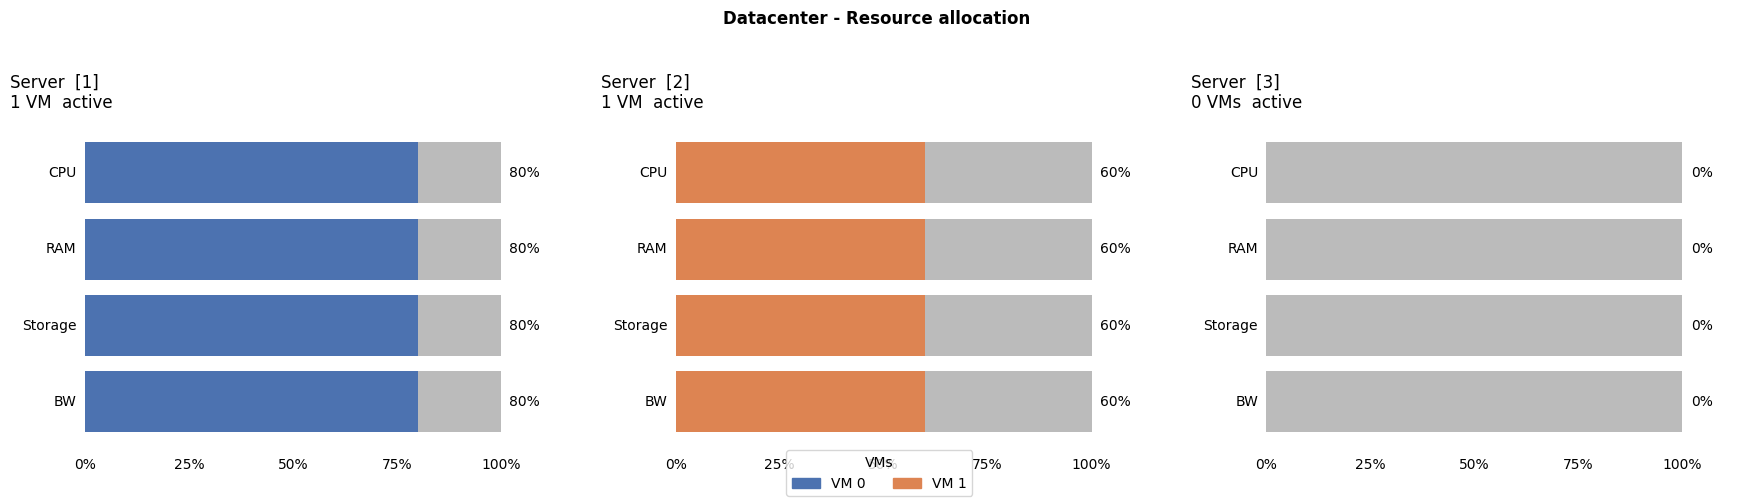

In [14]:
solution, remaining_space, remaining_minus_most_empty = test_case_3(FFDSolver())
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()

### PLNE (migration weight = 0.5, fragmentation weight = 0.5)

Scores : (4, 0)


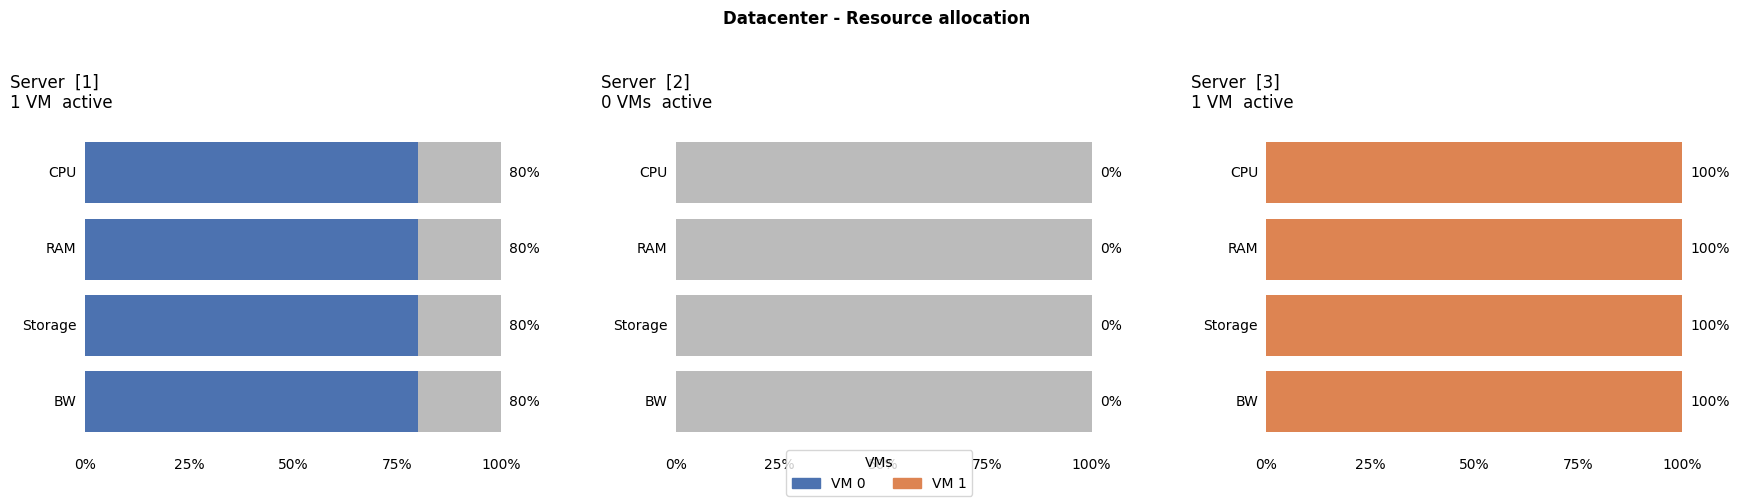

In [15]:
solution, remaining_space, remaining_minus_most_empty = test_case_3(PLNESolver(0.5, 0.5))
print(f"Scores : {(remaining_space, remaining_minus_most_empty)}")
solution.plot()